# Train Action-Chunking-Transformer (ACT) on your Dataset
Train the ACT model on your custom dataset. In this example, we set chunk_size as 10. 

In [1]:
import torch
import sys
sys.path.append('/home/student/Desktop/lerobot-papras')
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.datasets.utils import dataset_to_policy_features
from lerobot.policies.act.configuration_act import ACTConfig
from lerobot.policies.act.modeling_act import ACTPolicy
from lerobot.configs.types import FeatureType
from lerobot.datasets.factory import resolve_delta_timestamps
from torch.utils.data import ConcatDataset

In [2]:
device = torch.device("cuda")

# Number of offline training steps (we'll only do offline training for this example.)
# Adjust as you prefer. 5000 steps are needed to get something worth evaluating.
training_steps = 5000
log_freq = 100

## Policy Configuration and Initialize

chunk_size = 10

In [16]:
# When starting from scratch (i.e. not from a pretrained policy), we need to specify 2 things before
# creating the policy:
#   - input/output shapes: to properly size the policy
#   - dataset stats: for normalization and denormalization of input/outputs
dataset_metadata = LeRobotDatasetMetadata("nov_19_e20", root='./nov_19_e20')
features = dataset_to_policy_features(dataset_metadata.features)
output_features = {key: ft for key, ft in features.items() if ft.type is FeatureType.ACTION}
input_features = {key: ft for key, ft in features.items() if key not in output_features}
input_features.pop("observation.wrist_image")
# Policies are initialized with a configuration class, in this case `DiffusionConfig`. For this example,
# we'll just use the defaults and so no arguments other than input/output features need to be passed.
cfg = ACTConfig(input_features=input_features, output_features=output_features, chunk_size= 10, n_action_steps=10)
# This allows us to construct the data with action chunking
delta_timestamps = resolve_delta_timestamps(cfg, dataset_metadata)
# We can now instantiate our policy with this config and the dataset stats.
policy = ACTPolicy(cfg)
policy.train()
policy.to(device)

ACTPolicy(
  (model): ACT(
    (vae_encoder): ACTEncoder(
      (layers): ModuleList(
        (0-3): 4 x ACTEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=3200, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=3200, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
      (norm): Identity()
    )
    (vae_encoder_cls_embed): Embedding(1, 512)
    (vae_encoder_robot_state_input_proj): Linear(in_features=6, out_features=512, bias=True)
    (vae_encoder_action_input_proj): Linear(in_features=8, out_features=512, bias

## Load Dataset

In [17]:
from torchvision import transforms

class AddGaussianNoise(object):
    """
    Adds Gaussian noise to a tensor.
    """
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        # Adds noise: tensor remains a tensor.
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"

# Create a transformation pipeline that converts a PIL image to a tensor, then adds noise.
transform = transforms.Compose([
    AddGaussianNoise(mean=0., std=0.02),
    transforms.Lambda(lambda x: x.clamp(0, 1))
])


In [18]:
# We can then instantiate the dataset with these delta_timestamps configuration.
dataset = LeRobotDataset("nov_19e_20", delta_timestamps=delta_timestamps, root='./nov_19_e20', image_transforms=transform)

# Then we create our optimizer and dataloader for offline training.
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-4)
dataloader = torch.utils.data.DataLoader(
    dataset,
    num_workers=4,
    batch_size=64,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)


## Train

The trained checkpoint will be saved in './ckpt/act_y' folder.

In [20]:
# Run training loop.
step = 0
done = False
while not done:
    for batch in dataloader:
        inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        loss, _ = policy.forward(inp_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if step % log_freq == 0:
            print(f"step: {step} loss: {loss.item():.3f}")
        step += 1
        if step >= training_steps:
            done = True
            break


step: 0 loss: 0.241
step: 100 loss: 0.210
step: 200 loss: 0.203
step: 300 loss: 0.184
step: 400 loss: 0.165
step: 500 loss: 0.158
step: 600 loss: 0.139
step: 700 loss: 0.132
step: 800 loss: 0.137
step: 900 loss: 0.130
step: 1000 loss: 0.117
step: 1100 loss: 0.113
step: 1200 loss: 0.110
step: 1300 loss: 0.104
step: 1400 loss: 0.091
step: 1500 loss: 0.090
step: 1600 loss: 0.088
step: 1700 loss: 0.086
step: 1800 loss: 0.076
step: 1900 loss: 0.081
step: 2000 loss: 0.080
step: 2100 loss: 0.074
step: 2200 loss: 0.068
step: 2300 loss: 0.064
step: 2400 loss: 0.066
step: 2500 loss: 0.061
step: 2600 loss: 0.061
step: 2700 loss: 0.059
step: 2800 loss: 0.057
step: 2900 loss: 0.058


In [21]:
# Save the policy to disk.
policy.save_pretrained('./ckpt/act_y')

## Test Inference

To evaluate the policy on the dataset, you can calculate the error between ground-truth actions from the dataset.

In [22]:
import torch

class EpisodeSampler(torch.utils.data.Sampler):
    """
    Sampler for a single episode
    """
    def __init__(self, dataset: LeRobotDataset, episode_index: int):
        episode = dataset.meta.episodes.filter(lambda example: example["episode_index"]==episode_index)[0]
        from_idx = episode["dataset_from_index"],
        to_idx = episode["dataset_to_index"]
        # print(from_idx, to_idx)
        self.frame_ids = range(from_idx[0], to_idx)

    def __iter__(self):
        return iter(self.frame_ids)

    def __len__(self) -> int:
        return len(self.frame_ids)

In [24]:
policy.eval()
actions = []
gt_actions = []
images = []
episode_index = 0
episode_sampler = EpisodeSampler(dataset, episode_index)
test_dataloader = torch.utils.data.DataLoader(
    dataset,
    num_workers=4,
    batch_size=1,
    shuffle=False,
    pin_memory=device.type != "cpu",
    sampler=episode_sampler,
)
policy.reset()
for batch in test_dataloader:
    inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    action = policy.select_action(inp_batch)
    actions.append(action)
    gt_actions.append(inp_batch["action"][:,0,:])
    images.append(inp_batch["observation.image"])
actions = torch.cat(actions, dim=0)
gt_actions = torch.cat(gt_actions, dim=0)
print(f"Mean action error: {torch.mean(torch.abs(actions - gt_actions)).item():.3f}")

Mean action error: 0.035


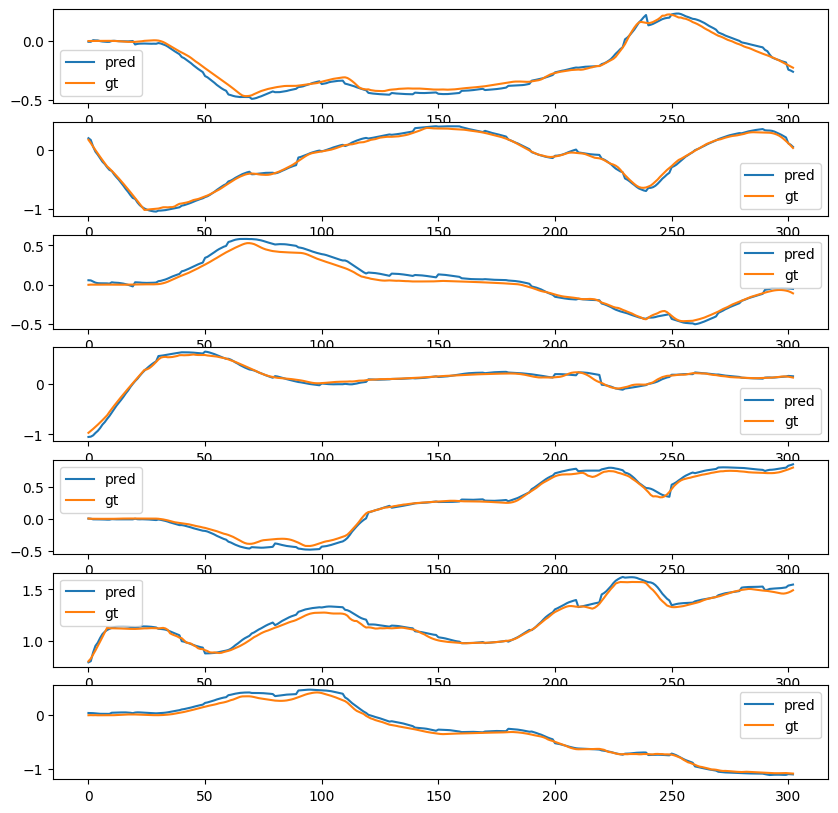

In [25]:
'''
plot actions and gt_actions
'''
import matplotlib.pyplot as plt
action_dim = 7

fig, axs = plt.subplots(action_dim, 1, figsize=(10, 10))

for i in range(action_dim):
    axs[i].plot(actions[:, i].cpu().detach().numpy(), label="pred")
    axs[i].plot(gt_actions[:, i].cpu().detach().numpy(), label="gt")
    axs[i].legend()
plt.show()